In [ ]:
!pip install tensorflow==2.15.0
!pip install keras==2.15.0
!pip install matplotlib
!pip install numpy
!pip install pandas
!pip install sklearn
!pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1
  Attempting uninstall: tensorboard
    Found existing installation

In [ ]:
import tensorflow as tf

import keras
from keras import datasets
from keras.layers import Dense, Flatten, Dropout, Activation, BatchNormalization
from keras.layers import PReLU, LeakyReLU, Conv2D, MaxPool2D, Lambda
from keras.regularizers import l2
import yfinance as yf
from keras.models import model_from_json

from IPython.display import clear_output

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.ticker import MaxNLocator

import pickle
import sklearn as skl

from sklearn import datasets, linear_model
from sklearn.model_selection import cross_val_score

In [ ]:
#fetch stock price data from yahoo
def fetch_stock_data(symbol, period='5y'):
    stock_data = yf.Ticker(symbol)
    df = stock_data.history(period=period)
    return df['Close'].values  # Return closing prices as a 1D array

# Example: Fetch data for Apple stock
data = fetch_stock_data("AAPL", period='5y')  # Fetch 5 years of data
print(data)  # Print the fetched data

[ 58.84725952  60.17777634  61.88567734 ... 231.41000366 233.3999939
 233.66999817]


In [ ]:
#create sequences and targets using a sliding window
def create_sequences(data, seq_length=60):
    sequences = []
    targets = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])  # Sequence of length `seq_length`
        targets.append(data[i+seq_length])      # Target is the next price after the sequence
    return np.array(sequences), np.array(targets)

sequence_length = 60  # Define number of time steps in each input sequence
X, y = create_sequences(data, sequence_length)

In [ ]:
# Step 3: Reshape for Conv1D Layer Compatibility
X = X.reshape((X.shape[0], X.shape[1], 1))  # Reshape to (num_sequences, sequence_length, 1)

# Step 4: Split Data into Training and Validation Sets
split_idx = int(0.8 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

In [ ]:
inputs = keras.layers.Input(shape=(sequence_length, 1))

# Block 1
x = keras.layers.Conv1D(128, 1, activation='relu', padding='same')(inputs)
x = keras.layers.Conv1D(128, 1, activation='relu', padding='same')(x)
x = keras.layers.MaxPooling1D(2)(x)

# Block 2
x = keras.layers.Conv1D(128, 1, activation='relu', padding='same')(x)
x = keras.layers.Conv1D(128, 1, activation='relu', padding='same')(x)
x = keras.layers.MaxPooling1D(1)(x)

# Block 3
x = keras.layers.Conv1D(128, 2, activation='relu', padding='same')(x)
x = keras.layers.Conv1D(128, 2, activation='relu', padding='same')(x)
x = keras.layers.Conv1D(128, 2, activation='relu', padding='same')(x)
x = keras.layers.MaxPooling1D(1)(x)

# Flatten and dense layers for regression
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(2000, activation='relu')(x)
x = keras.layers.Dropout(0.1)(x)
x = keras.layers.Dense(2000, activation='relu')(x)
x = keras.layers.Dropout(0.1)(x)
output = keras.layers.Dense(1)(x)  # Single neuron for price prediction

# Create and compile the model
model = keras.models.Model(inputs=inputs, outputs=output)
opt = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='mse', metrics=['mae'])

# Display model summary
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 60, 1)]           0         
                                                                 
 conv1d_7 (Conv1D)           (None, 60, 128)           256       
                                                                 
 conv1d_8 (Conv1D)           (None, 60, 128)           16512     
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 30, 128)           0         
 g1D)                                                            
                                                                 
 conv1d_9 (Conv1D)           (None, 30, 128)           16512     
                                                                 
 conv1d_10 (Conv1D)          (None, 30, 128)           16512     
                                                           

In [ ]:
# Step 6: Train the Model on Sequential Data
history = model.fit(
    X_train, y_train,
    batch_size=32, epochs=20,
    validation_data=(X_val, y_val)
)

Epoch 1/20
30/30 [==============================] - 10s 279ms/step - loss: 3568.6736 - mae: 43.0983 - val_loss: 508.9729 - val_mae: 20.1100
Epoch 2/20
30/30 [==============================] - 6s 188ms/step - loss: 196.2159 - mae: 10.9622 - val_loss: 214.4268 - val_mae: 11.6567
Epoch 3/20
30/30 [==============================] - 7s 243ms/step - loss: 116.8504 - mae: 8.8331 - val_loss: 144.1540 - val_mae: 9.7140
Epoch 4/20
30/30 [==============================] - 6s 186ms/step - loss: 110.8279 - mae: 8.5858 - val_loss: 135.0521 - val_mae: 9.4268
Epoch 5/20
30/30 [==============================] - 7s 236ms/step - loss: 107.1779 - mae: 8.4201 - val_loss: 140.7606 - val_mae: 9.5728
Epoch 6/20
30/30 [==============================] - 8s 251ms/step - loss: 103.3344 - mae: 8.2884 - val_loss: 134.6713 - val_mae: 9.3655
Epoch 7/20
30/30 [==============================] - 8s 260ms/step - loss: 97.1863 - mae: 8.0194 - val_loss: 112.3549 - val_mae: 8.5961
Epoch 8/20
30/30 [=========================

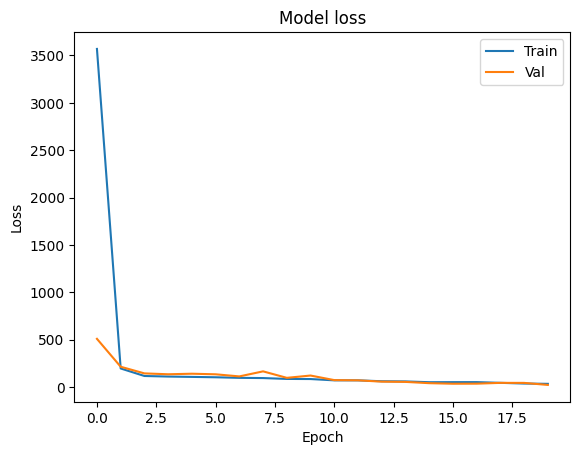

In [ ]:
#Plot Training and Validation Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

3/3 [==============================] - 0s 21ms/step
Predicted Prices: [[233.72356]
 [233.94492]
 [232.07652]
 [232.63046]
 [233.07748]]
Predicted Prices: [233.72356 233.94492 232.07652 232.63046 233.07748]
Actual Prices: [230.75999451 230.57000732 231.41000366 233.3999939  233.66999817]


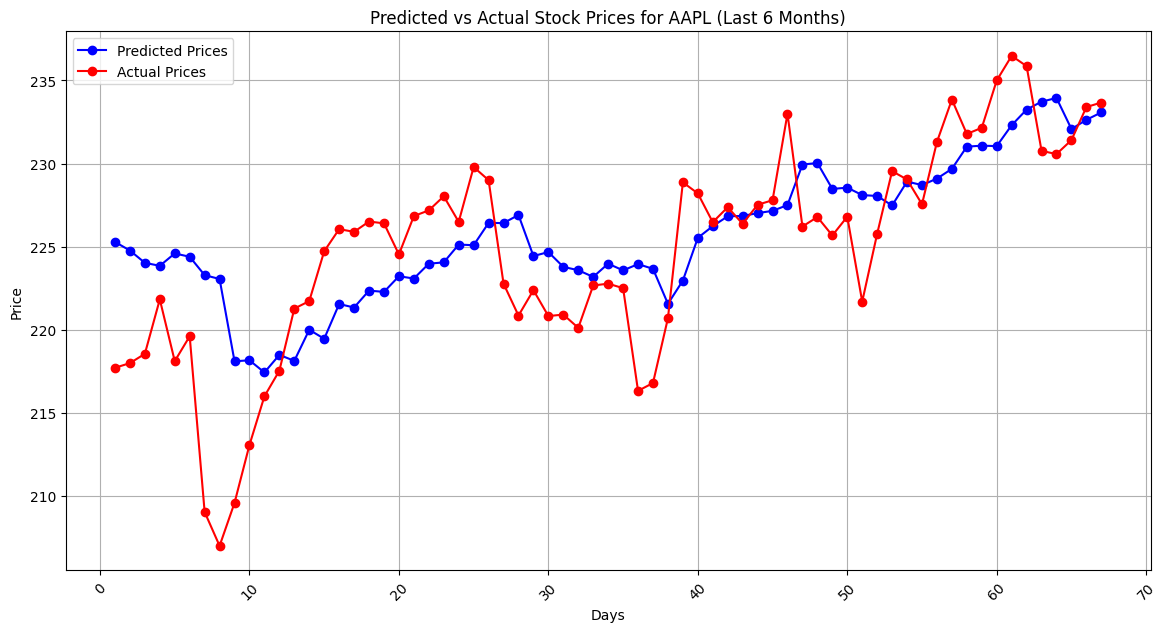

In [ ]:
# Step 7: Fetch more data to ensure enough points
# Fetching 6 months of data for prediction
new_data = fetch_stock_data("AAPL", period='6mo')  # Fetch 6 months of data

if len(new_data) >= sequence_length:
    X_new, _ = create_sequences(new_data, sequence_length)
    X_new = X_new.reshape((X_new.shape[0], X_new.shape[1], 1))

    # Predict the next prices
    predicted_prices = model.predict(X_new)
    print("Predicted Prices:", predicted_prices[-5:])  # Show last 5 predictions

    # Fetch actual prices for the last 6 months (approx. 126 trading days)
    actual_data = fetch_stock_data("AAPL", period='6mo')  # Get actual prices for the last 6 months
    actual_prices = actual_data[-len(predicted_prices):]  # Ensure the length matches the predicted prices

    # Ensure prices are in a compatible format
    predicted_prices_flat = predicted_prices.flatten()  # Flatten the predicted prices
    actual_prices_flat = actual_prices.flatten()  # Ensure actual prices are flat

    # Print predicted and actual prices for comparison
    print("Predicted Prices:", predicted_prices_flat[-5:])  # Show the last 5 predicted prices for comparison
    print("Actual Prices:", actual_prices_flat[-5:])  # Show the last 5 actual prices for comparison
     # Visualize the comparison
    plt.figure(figsize=(14, 7))
    plt.plot(range(1, len(predicted_prices_flat)+1), predicted_prices_flat, marker='o', label='Predicted Prices', color='blue')
    plt.plot(range(1, len(actual_prices_flat)+1), actual_prices_flat, marker='o', label='Actual Prices', color='red')
    plt.title('Predicted vs Actual Stock Prices for AAPL (Last 6 Months)')
    plt.xlabel('Days')
    plt.ylabel('Price')
    plt.xticks(rotation=45)  # Adjust x-ticks for better visibility
    plt.legend()
    plt.grid()
    plt.show()
else:
    print(f"Not enough data to create sequences. Data length: {len(new_data)}; required: {sequence_length}")
